# Multimodal Skin Lesion Classification: A Leakage-Controlled Empirical Study on Image, Metadata, and Gated Fusion

### 🎯 Research Questions:
1. **RQ1 (Metadata Diagnostic Signal):** Does demographic and anatomical metadata alone provide useful diagnostic signal for skin-lesion classification?
2. **RQ2 (Multimodal Synergy):** Does fusing clinical metadata with dermoscopic imagery improve class-balanced sensitivity on clinically important minority classes, particularly melanoma, compared to an identically fine-tuned image-only baseline?
3. **RQ3 (Gating Mechanism):** Does learned **Gated Multimodal Fusion** provide a measurable advantage over strictly controlled **Simple Feature Concatenation**?

---

### 🔬 Controlled Experimental Matrix:
- **Model 1 (M1):** Metadata-Only Tabular Network (19 features)
- **Model 2 (M2):** Image-Only EfficientNetB0 (Identical 2-Stage Surgical Fine-Tuning)
- **Model 3 (M3):** Simple Concatenation Fusion (Controlled identical sub-branches)
- **Model 4 (M4 - Proposed):** Gated Multimodal Fusion (Sigmoid Modality Interaction Gate)
- **Statistical Significance:** Exact McNemar's Test ($p < 0.05$) & 1,000-Iteration Lesion-Clustered Bootstrap ($95\%$ CI with multiplicity preservation)
- **Ablations:** (1) Metadata Permutation & Zeroing Ablation, (2) DullRazor Inference Sensitivity Analysis
- **Explainability:** Genuine Gradient-Weighted Class Activation Mapping (Grad-CAM)
- **Auto-Caching:** Automatic pre-trained model detection to skip retraining on subsequent runs.

## 1. Environment Setup & Core Dependencies

In [40]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib

try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    mcnemar = None

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Centralized Configuration Registry (`Config`) & Model Search Helper

In [41]:
class Config:
    SEED = 50
    FORCE_RETRAIN = True  # Set to True if you want to force retraining from scratch
    
    # Dataset Paths
    DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
    if not os.path.exists(DATA_DIR):
        DATA_DIR = "/kaggle/input/skin-cancer-mnist-ham10000"
    
    METADATA_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv") if os.path.exists(DATA_DIR) else "HAM10000_metadata.csv"
    IMAGE_DIRS = [
        os.path.join(DATA_DIR, "HAM10000_images_part_1"),
        os.path.join(DATA_DIR, "HAM10000_images_part_2")
    ]
    
    MODEL_DIR = "/kaggle/working/models"
    OUTPUT_DIR = "/kaggle/working/outputs"
    
    IMAGE_HEIGHT = 224
    IMAGE_WIDTH = 224
    IMAGE_CHANNELS = 3
    IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
    BATCH_SIZE = 32
    NUM_CLASSES = 7
    
    TARGET_COLUMN = "dx"
    GROUP_COLUMN = "lesion_id"
    IMAGE_ID_COLUMN = "image_id"
    
    NUMERIC_FEATURES = ["age"]
    CATEGORICAL_FEATURES = ["sex", "localization"]
    METADATA_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
    
    CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
    
    # Training Parameters
    STAGE_1_EPOCHS = 15
    STAGE_1_LR = 1e-3
    STAGE_2_EPOCHS = 20
    STAGE_2_LR = 1e-5
    UNFREEZE_PERCENTAGE = 0.20
    
    # Loss Parameters
    FOCAL_GAMMA = 2.0
    FOCAL_ALPHA = 0.25

os.makedirs(Config.MODEL_DIR, exist_ok=True)
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

# Deterministic Seed Setting
os.environ["PYTHONHASHSEED"] = str(Config.SEED)
random.seed(Config.SEED)
np.random.seed(Config.SEED)
tf.random.set_seed(Config.SEED)

def find_saved_model_path(model_filename):
    """Searches working directory and attached Kaggle datasets strictly for the exact requested filename."""
    if Config.FORCE_RETRAIN:
        return None
    
    # 1. Check local working directory
    working_path = os.path.join(Config.MODEL_DIR, model_filename)
    if os.path.exists(working_path):
        return working_path
    
    # 2. Check attached Kaggle inputs/datasets
    if os.path.exists("/kaggle/input"):
        for root, _, files in os.walk("/kaggle/input"):
            if model_filename in files:
                return os.path.join(root, model_filename)
                
    # 3. Check current folder
    if os.path.exists(model_filename):
        return model_filename
    if os.path.exists(os.path.join("models", model_filename)):
        return os.path.join("models", model_filename)
        
    return None

print("Configuration Registry Initialized.")

Configuration Registry Initialized.


## 3. DullRazor Morphological Artifact Reduction

In [42]:
def apply_dull_razor_np(image_bytes):
    """
    Reduces hair-like dark artifacts using morphological black-hat detection and inpainting.
    """
    img = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (Config.IMAGE_WIDTH, Config.IMAGE_HEIGHT))
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, thresh = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    inpainted = cv2.inpaint(img, thresh, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted.astype(np.float32)

def load_raw_image_np(image_bytes):
    """Loads raw resized image without DullRazor filtering for preprocessing sensitivity analysis."""
    img = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (Config.IMAGE_WIDTH, Config.IMAGE_HEIGHT))
    return img.astype(np.float32)

print("Image Preprocessing Modules Registered.")

Image Preprocessing Modules Registered.


## 4. Dataset Ingestion & Complete 3-Way Lesion Isolation Split

In [43]:
metadata = pd.read_csv(Config.METADATA_PATH)

image_records = []
for directory in Config.IMAGE_DIRS:
    if os.path.exists(directory):
        for filename in sorted(os.listdir(directory)):
            extension = os.path.splitext(filename)[1].lower()
            if extension in {".jpg", ".jpeg", ".png"}:
                image_records.append({
                    Config.IMAGE_ID_COLUMN: os.path.splitext(filename)[0],
                    "image_path": os.path.join(directory, filename)
                })

image_files = pd.DataFrame(image_records).sort_values(Config.IMAGE_ID_COLUMN).reset_index(drop=True)
metadata = metadata.merge(image_files, on=Config.IMAGE_ID_COLUMN, how="inner", validate="one_to_one")
print("Total verified aligned image-metadata records:", len(metadata))

# Canonical Stratified Group Split on lesion_id
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=Config.SEED)
metadata["split_fold"] = -1

for fold, (_, val_indices) in enumerate(
    sgkf.split(metadata, metadata[Config.TARGET_COLUMN], groups=metadata[Config.GROUP_COLUMN])
):
    metadata.loc[val_indices, "split_fold"] = fold

TEST_FOLD = 0
VALIDATION_FOLD = 1

metadata["split"] = "train"
metadata.loc[metadata["split_fold"] == VALIDATION_FOLD, "split"] = "validation"
metadata.loc[metadata["split_fold"] == TEST_FOLD, "split"] = "test"

train_df = metadata[metadata["split"] == "train"].copy().reset_index(drop=True)
val_df = metadata[metadata["split"] == "validation"].copy().reset_index(drop=True)
test_df = metadata[metadata["split"] == "test"].copy().reset_index(drop=True)

# Full 3-Way Lesion Isolation Verification
train_lesions = set(train_df[Config.GROUP_COLUMN])
val_lesions = set(val_df[Config.GROUP_COLUMN])
test_lesions = set(test_df[Config.GROUP_COLUMN])

assert len(train_lesions & val_lesions) == 0, "Leakage between train and validation!"
assert len(train_lesions & test_lesions) == 0, "Leakage between train and test!"
assert len(val_lesions & test_lesions) == 0, "Leakage between validation and test!"
print(f"✓ Zero-Leakage Lesion Isolation Verified: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")

Total verified aligned image-metadata records: 10015
✓ Zero-Leakage Lesion Isolation Verified: Train=7146 | Val=1417 | Test=1452


## 5. Tabular Metadata Transformation Pipeline (19 Features)

In [44]:
CLASS_TO_INDEX = {c: i for i, c in enumerate(Config.CLASS_NAMES)}
INDEX_TO_CLASS = {i: c for i, c in enumerate(Config.CLASS_NAMES)}

def encode_target(series):
    return series.map(CLASS_TO_INDEX).astype(np.int32).to_numpy()

y_train_array = encode_target(train_df[Config.TARGET_COLUMN])
y_val_array = encode_target(val_df[Config.TARGET_COLUMN])
y_test_array = encode_target(test_df[Config.TARGET_COLUMN])

train_processed = train_df.copy()
val_processed = val_df.copy()
test_processed = test_df.copy()

for df in [train_processed, val_processed, test_processed]:
    df["age"] = df["age"].replace(0, np.nan)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

metadata_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, Config.NUMERIC_FEATURES),
    ("categorical", categorical_pipeline, Config.CATEGORICAL_FEATURES)
])

# Fit on training data ONLY to prevent preprocessing leakage
x_train_metadata_processed = metadata_preprocessor.fit_transform(train_processed[Config.METADATA_FEATURES]).astype(np.float32)
x_val_metadata_processed = metadata_preprocessor.transform(val_processed[Config.METADATA_FEATURES]).astype(np.float32)
x_test_metadata_processed = metadata_preprocessor.transform(test_processed[Config.METADATA_FEATURES]).astype(np.float32)

METADATA_FEATURE_DIM = x_train_metadata_processed.shape[1]
print(f"Engineered Metadata Feature Dimension: {METADATA_FEATURE_DIM} (Expected 19)")
joblib.dump(metadata_preprocessor, os.path.join(Config.MODEL_DIR, "metadata_preprocessor.joblib"))

Engineered Metadata Feature Dimension: 19 (Expected 19)


['/kaggle/working/models/metadata_preprocessor.joblib']

## 6. Class Weighting & Sparse Categorical Focal Loss (Per-Sample)

In [45]:
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_array),
    y=y_train_array
)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}

try:
    register_serializable = tf.keras.utils.register_keras_serializable
except AttributeError:
    try:
        register_serializable = keras.saving.register_keras_serializable
    except AttributeError:
        register_serializable = lambda **kwargs: (lambda cls: cls)

@register_serializable(package="CustomLoss")
class SparseCategoricalFocalLoss(keras.losses.Loss):
    """
    Sparse Categorical Focal Loss returning per-sample loss vector.
    This enables Keras class_weight and sample_weight to be accurately applied.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=Config.FOCAL_GAMMA, alpha=Config.FOCAL_ALPHA, name="sparse_categorical_focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def call(self, y_true, y_pred):
        y_true_flat = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_one_hot = tf.one_hot(y_true_flat, depth=Config.NUM_CLASSES)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = self.alpha * y_true_one_hot * tf.math.pow(1.0 - y_pred, self.gamma)
        # Return per-sample loss vector of shape (batch_size,)
        loss = tf.reduce_sum(weight * cross_entropy, axis=-1)
        return loss

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma, "alpha": self.alpha})
        return config

focal_loss_fn = SparseCategoricalFocalLoss()
print("Balanced Class Weights and Per-Sample Focal Loss ready.")

Balanced Class Weights and Per-Sample Focal Loss ready.


## 7. High-Performance `tf.data` Pipeline with `.cache()`

In [46]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10, 0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

def load_and_clean_image(image_path, use_dull_razor=True):
    raw_bytes = tf.io.read_file(image_path)
    fn = apply_dull_razor_np if use_dull_razor else load_raw_image_np
    cleaned_img = tf.numpy_function(func=fn, inp=[raw_bytes], Tout=tf.float32)
    cleaned_img.set_shape([Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH, Config.IMAGE_CHANNELS])
    return cleaned_img

def create_multimodal_dataset(df, metadata_array, labels, training=False, use_dull_razor=True):
    paths = df["image_path"].values
    dataset = tf.data.Dataset.from_tensor_slices((paths, metadata_array, labels))
    
    def load_base(image_path, meta, label):
        img = load_and_clean_image(image_path, use_dull_razor=use_dull_razor)
        return {"image": img, "metadata": tf.cast(meta, tf.float32)}, tf.cast(label, tf.int32)

    dataset = dataset.map(load_base, num_parallel_calls=AUTOTUNE).cache()
    if training:
        dataset = dataset.shuffle(len(df), reshuffle_each_iteration=True)
        def augment_base(inputs, label):
            aug_img = data_augmentation(inputs["image"], training=True)
            return {"image": aug_img, "metadata": inputs["metadata"]}, label
        dataset = dataset.map(augment_base, num_parallel_calls=AUTOTUNE)

    return dataset.batch(Config.BATCH_SIZE).prefetch(AUTOTUNE)

def create_image_only_dataset(df, labels, training=False, use_dull_razor=True):
    paths = df["image_path"].values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    def load_img(image_path, label):
        img = load_and_clean_image(image_path, use_dull_razor=use_dull_razor)
        return img, tf.cast(label, tf.int32)

    dataset = dataset.map(load_img, num_parallel_calls=AUTOTUNE).cache()
    if training:
        dataset = dataset.shuffle(len(df), reshuffle_each_iteration=True)
        dataset = dataset.map(lambda img, lbl: (data_augmentation(img, training=True), lbl), num_parallel_calls=AUTOTUNE)
    return dataset.batch(Config.BATCH_SIZE).prefetch(AUTOTUNE)

train_dataset = create_multimodal_dataset(train_df, x_train_metadata_processed, y_train_array, training=True)
val_dataset = create_multimodal_dataset(val_df, x_val_metadata_processed, y_val_array, training=False)
test_dataset = create_multimodal_dataset(test_df, x_test_metadata_processed, y_test_array, training=False)

img_train_ds = create_image_only_dataset(train_df, y_train_array, training=True)
img_val_ds = create_image_only_dataset(val_df, y_val_array, training=False)
img_test_ds = create_image_only_dataset(test_df, y_test_array, training=False)
print("Streaming Datasets Initialized.")

Streaming Datasets Initialized.


## 8. Model 1: Metadata-Only Tabular Baseline (RQ1)

In [47]:
M1_MODEL_PATH = os.path.join(Config.MODEL_DIR, "metadata_only_model.keras")
saved_m1 = find_saved_model_path("metadata_only_model.keras")

if saved_m1:
    print(f"✅ Found pre-trained Model 1 at: {saved_m1}! Loading without retraining...")
    metadata_only_model = keras.models.load_model(saved_m1, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})
    history_m1 = None
else:
    print("⏳ Building & Training Model 1: Metadata-Only Baseline...")
    meta_input = keras.Input(shape=(METADATA_FEATURE_DIM,), name="metadata_input")
    x_meta = layers.Dense(64, activation="relu")(meta_input)
    x_meta = layers.BatchNormalization()(x_meta)
    x_meta = layers.Dropout(0.3)(x_meta)
    x_meta = layers.Dense(32, activation="relu")(x_meta)
    x_meta = layers.Dropout(0.2)(x_meta)
    meta_out = layers.Dense(Config.NUM_CLASSES, activation="softmax", name="meta_classification")(x_meta)

    metadata_only_model = keras.Model(inputs=meta_input, outputs=meta_out, name="metadata_only_model")
    metadata_only_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss_fn,
        metrics=["accuracy"]
    )

    meta_callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    ]
    history_m1 = metadata_only_model.fit(
        x_train_metadata_processed, y_train_array,
        validation_data=(x_val_metadata_processed, y_val_array),
        epochs=35,
        batch_size=64,
        class_weight=class_weights_dict,
        callbacks=meta_callbacks,
        verbose=1
    )
    metadata_only_model.save(M1_MODEL_PATH)
    print(f"Saved M1 to: {M1_MODEL_PATH}")

✅ Found pre-trained Model 1 at: /kaggle/working/models/metadata_only_model.keras! Loading without retraining...


## 9. Model 2: Image-Only EfficientNetB0 Baseline (Identical 2-Stage Protocol)

In [48]:
M2_MODEL_PATH = os.path.join(Config.MODEL_DIR, "image_only_model.keras")
saved_m2 = find_saved_model_path("image_only_model.keras")

if saved_m2:
    print(f"✅ Found pre-trained Model 2 at: {saved_m2}! Loading without retraining...")
    image_only_model = keras.models.load_model(saved_m2, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})
    history_m2_stage2 = None
else:
    print("⏳ Building & Training Model 2: Image-Only EfficientNetB0 Baseline...")
    img_backbone = keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH, Config.IMAGE_CHANNELS)
    )
    img_backbone.trainable = False

    img_in = keras.Input(shape=(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH, Config.IMAGE_CHANNELS), name="img_input")
    x_img = img_backbone(img_in, training=False)
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation="relu")(x_img)
    x_img = layers.BatchNormalization()(x_img)
    x_img = layers.Dropout(0.3)(x_img)
    img_out = layers.Dense(Config.NUM_CLASSES, activation="softmax", name="img_classification")(x_img)

    image_only_model = keras.Model(inputs=img_in, outputs=img_out, name="image_only_model")

    # Stage 1: Warmup
    print("=== Image-Only: Stage 1 Warmup ===")
    image_only_model.compile(optimizer=keras.optimizers.Adam(learning_rate=Config.STAGE_1_LR), loss=focal_loss_fn, metrics=["accuracy"])
    history_m2_stage1 = image_only_model.fit(
        img_train_ds, validation_data=img_val_ds, epochs=Config.STAGE_1_EPOCHS, class_weight=class_weights_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=1
    )

    # Stage 2: Surgical Fine-Tuning
    print("\n=== Image-Only: Stage 2 Fine-Tuning ===")
    img_backbone.trainable = True
    num_layers = len(img_backbone.layers)
    unfreeze_from = int(num_layers * (1.0 - Config.UNFREEZE_PERCENTAGE))

    for i, layer in enumerate(img_backbone.layers):
        if i < unfreeze_from or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    image_only_model.compile(optimizer=keras.optimizers.Adam(learning_rate=Config.STAGE_2_LR), loss=focal_loss_fn, metrics=["accuracy"])
    history_m2_stage2 = image_only_model.fit(
        img_train_ds, validation_data=img_val_ds, epochs=Config.STAGE_2_EPOCHS, class_weight=class_weights_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)],
        verbose=1
    )
    image_only_model.save(M2_MODEL_PATH)
    print(f"Saved M2 to: {M2_MODEL_PATH}")

✅ Found pre-trained Model 2 at: /kaggle/working/models/image_only_model.keras! Loading without retraining...


## 10. Model 3: Simple Concatenation Multimodal Fusion Baseline (Strictly Controlled)

In [49]:
M3_MODEL_PATH = os.path.join(Config.MODEL_DIR, "simple_concat_fusion.keras")
saved_m3 = find_saved_model_path("simple_concat_fusion.keras")

if saved_m3:
    print(f"✅ Found pre-trained Model 3 at: {saved_m3}! Loading without retraining...")
    concat_fusion_model = keras.models.load_model(saved_m3, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})
    history_m3_stage2 = None
else:
    print("⏳ Building & Training Model 3: Simple Concatenation Fusion Baseline...")
    concat_backbone = keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH, Config.IMAGE_CHANNELS)
    )
    concat_backbone.trainable = False

    in_img_c = keras.Input(shape=(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH, Config.IMAGE_CHANNELS), name="image")
    feat_img_c = concat_backbone(in_img_c, training=False)
    feat_img_c = layers.GlobalAveragePooling2D(name="img_global_pool_c")(feat_img_c)
    feat_img_c = layers.Dense(128, activation="relu", name="img_dense_embed_c")(feat_img_c)
    feat_img_c = layers.BatchNormalization(name="img_bn_c")(feat_img_c)
    feat_img_c = layers.Dropout(0.3, name="img_dropout_c")(feat_img_c)

    in_meta_c = keras.Input(shape=(METADATA_FEATURE_DIM,), name="metadata")
    feat_meta_c = layers.Dense(64, activation="relu", name="meta_dense_1_c")(in_meta_c)
    feat_meta_c = layers.BatchNormalization(name="meta_bn_c")(feat_meta_c)
    feat_meta_c = layers.Dropout(0.2, name="meta_dropout_c")(feat_meta_c)
    feat_meta_c = layers.Dense(128, activation="relu", name="meta_dense_embed_c")(feat_meta_c)

    # Direct Concatenation (Identical classifier head without gate)
    fused_concat = layers.Concatenate(name="simple_concat")([feat_img_c, feat_meta_c])
    x_c = layers.Dense(128, activation="relu", name="fusion_dense_c")(fused_concat)
    x_c = layers.Dropout(0.3, name="fusion_dropout_c")(x_c)
    out_c = layers.Dense(Config.NUM_CLASSES, activation="softmax", name="classification_c")(x_c)

    concat_fusion_model = keras.Model(inputs={"image": in_img_c, "metadata": in_meta_c}, outputs=out_c, name="simple_concat_fusion")

    # Stage 1: Warmup
    print("=== Simple Concat: Stage 1 Warmup ===")
    concat_fusion_model.compile(optimizer=keras.optimizers.Adam(learning_rate=Config.STAGE_1_LR), loss=focal_loss_fn, metrics=["accuracy"])
    history_m3_stage1 = concat_fusion_model.fit(
        train_dataset, validation_data=val_dataset, epochs=Config.STAGE_1_EPOCHS, class_weight=class_weights_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=1
    )

    # Stage 2: Fine-Tuning
    print("\n=== Simple Concat: Stage 2 Fine-Tuning ===")
    concat_backbone.trainable = True
    num_layers = len(concat_backbone.layers)
    unfreeze_from = int(num_layers * (1.0 - Config.UNFREEZE_PERCENTAGE))

    for i, layer in enumerate(concat_backbone.layers):
        if i < unfreeze_from or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    concat_fusion_model.compile(optimizer=keras.optimizers.Adam(learning_rate=Config.STAGE_2_LR), loss=focal_loss_fn, metrics=["accuracy"])
    history_m3_stage2 = concat_fusion_model.fit(
        train_dataset, validation_data=val_dataset, epochs=Config.STAGE_2_EPOCHS, class_weight=class_weights_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)],
        verbose=1
    )
    concat_fusion_model.save(M3_MODEL_PATH)
    print(f"Saved M3 to: {M3_MODEL_PATH}")

✅ Found pre-trained Model 3 at: /kaggle/working/models/simple_concat_fusion.keras! Loading without retraining...


## 11. Model 4: Gated Multimodal Fusion Architecture (Proposed)

In [50]:
M4_MODEL_PATH = os.path.join(Config.MODEL_DIR, "gated_multimodal_fusion.keras")
saved_m4 = find_saved_model_path("gated_multimodal_fusion.keras")

if saved_m4:
    print(f"✅ Found pre-trained Model 4 at: {saved_m4}! Loading without retraining...")
    gated_fusion_model = keras.models.load_model(saved_m4, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})
    try:
        gated_backbone = gated_fusion_model.get_layer("efficientnetb0")
    except Exception:
        gated_backbone = [l for l in gated_fusion_model.layers if "efficientnet" in l.name.lower()][0]
    history_m4_stage2 = None
else:
    print("⏳ Building & Training Model 4: Gated Multimodal Fusion (Proposed)...")
    gated_backbone = keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH, Config.IMAGE_CHANNELS)
    )
    gated_backbone.trainable = False

    in_img_g = keras.Input(shape=(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH, Config.IMAGE_CHANNELS), name="image")
    feat_img_g = gated_backbone(in_img_g, training=False)
    feat_img_g = layers.GlobalAveragePooling2D(name="img_global_pool_g")(feat_img_g)
    feat_img_g = layers.Dense(128, activation="relu", name="img_dense_embed_g")(feat_img_g)
    feat_img_g = layers.BatchNormalization(name="img_bn_g")(feat_img_g)
    feat_img_g = layers.Dropout(0.3, name="img_dropout_g")(feat_img_g)

    in_meta_g = keras.Input(shape=(METADATA_FEATURE_DIM,), name="metadata")
    feat_meta_g = layers.Dense(64, activation="relu", name="meta_dense_1_g")(in_meta_g)
    feat_meta_g = layers.BatchNormalization(name="meta_bn_g")(feat_meta_g)
    feat_meta_g = layers.Dropout(0.2, name="meta_dropout_g")(feat_meta_g)
    feat_meta_g = layers.Dense(128, activation="relu", name="meta_dense_embed_g")(feat_meta_g)

    # Gating Mechanism: Sigmoid Modality Interaction Gate
    concat_raw = layers.Concatenate(name="raw_concat_g")([feat_img_g, feat_meta_g])
    gate = layers.Dense(128, activation="sigmoid", name="multimodal_gate_g")(concat_raw)
    gated_features = layers.Multiply(name="gated_interaction_g")([feat_img_g, gate])
    fused_gated = layers.Concatenate(name="fused_features_g")([gated_features, feat_meta_g])

    # Identical Classifier Head
    x_g = layers.Dense(128, activation="relu", name="fusion_dense_g")(fused_gated)
    x_g = layers.Dropout(0.3, name="fusion_dropout_g")(x_g)
    out_g = layers.Dense(Config.NUM_CLASSES, activation="softmax", name="classification_g")(x_g)

    gated_fusion_model = keras.Model(inputs={"image": in_img_g, "metadata": in_meta_g}, outputs=out_g, name="gated_multimodal_fusion")

    # Stage 1: Warmup
    print("=== Gated Fusion: Stage 1 Warmup ===")
    gated_fusion_model.compile(optimizer=keras.optimizers.Adam(learning_rate=Config.STAGE_1_LR), loss=focal_loss_fn, metrics=["accuracy"])
    history_m4_stage1 = gated_fusion_model.fit(
        train_dataset, validation_data=val_dataset, epochs=Config.STAGE_1_EPOCHS, class_weight=class_weights_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=1
    )

    # Stage 2: Surgical Fine-Tuning
    print("\n=== Gated Fusion: Stage 2 Fine-Tuning ===")
    gated_backbone.trainable = True
    num_layers = len(gated_backbone.layers)
    unfreeze_from = int(num_layers * (1.0 - Config.UNFREEZE_PERCENTAGE))

    for i, layer in enumerate(gated_backbone.layers):
        if i < unfreeze_from or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    gated_fusion_model.compile(optimizer=keras.optimizers.Adam(learning_rate=Config.STAGE_2_LR), loss=focal_loss_fn, metrics=["accuracy"])
    history_m4_stage2 = gated_fusion_model.fit(
        train_dataset, validation_data=val_dataset, epochs=Config.STAGE_2_EPOCHS, class_weight=class_weights_dict,
        callbacks=[
            keras.callbacks.ModelCheckpoint(M4_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1),
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
        ],
        verbose=1
    )
    gated_fusion_model.save(M4_MODEL_PATH)
    print(f"Saved M4 to: {M4_MODEL_PATH}")

✅ Found pre-trained Model 4 at: /kaggle/working/models/gated_multimodal_fusion.keras! Loading without retraining...


## 12. Learning Curves & Optimization Convergence

In [51]:
if history_m4_stage2 is not None and history_m3_stage2 is not None and history_m2_stage2 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Validation Loss across models
    axes[0].plot(history_m2_stage2.history['val_loss'], label='M2 Image-Only (Stage 2)', linestyle='--')
    axes[0].plot(history_m3_stage2.history['val_loss'], label='M3 Simple Concat (Stage 2)')
    axes[0].plot(history_m4_stage2.history['val_loss'], label='M4 Gated Fusion (Stage 2)', linewidth=2.5)
    axes[0].set_title("Validation Loss Trajectory (Fine-Tuning)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Validation Accuracy across models
    axes[1].plot(history_m2_stage2.history['val_accuracy'], label='M2 Image-Only (Stage 2)', linestyle='--')
    axes[1].plot(history_m3_stage2.history['val_accuracy'], label='M3 Simple Concat (Stage 2)')
    axes[1].plot(history_m4_stage2.history['val_accuracy'], label='M4 Gated Fusion (Stage 2)', linewidth=2.5)
    axes[1].set_title("Validation Accuracy Trajectory (Fine-Tuning)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_convergence_curves.png"), dpi=300)
    plt.show()
    print("Saved convergence plots to outputs/training_convergence_curves.png")
else:
    print("Pre-trained models loaded from disk; skipping training trajectory plot generation.")

Pre-trained models loaded from disk; skipping training trajectory plot generation.


## 13. Empirical Benchmark Evaluation & Complete Melanoma Clinical Diagnostics

In [52]:
def compute_full_clinical_metrics(y_true, y_probs, model_name):
    y_pred = np.argmax(y_probs, axis=1)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    
    # Class-specific binary metrics for Melanoma (mel)
    mel_idx = Config.CLASS_NAMES.index("mel")
    y_true_mel = (y_true == mel_idx).astype(int)
    y_pred_mel = (y_pred == mel_idx).astype(int)
    
    mel_prec = precision_score(y_true_mel, y_pred_mel, zero_division=0)
    mel_rec = recall_score(y_true_mel, y_pred_mel, zero_division=0)
    mel_f1 = f1_score(y_true_mel, y_pred_mel, zero_division=0)
    
    # Specificity = TN / (TN + FP)
    tn = np.sum((y_true_mel == 0) & (y_pred_mel == 0))
    fp = np.sum((y_true_mel == 0) & (y_pred_mel == 1))
    mel_spec = tn / (tn + fp + 1e-7)
    
    return {
        "Model": model_name,
        "Accuracy (%)": round(acc * 100, 2),
        "Balanced Acc (%)": round(bal_acc * 100, 2),
        "Macro F1": round(macro_f1, 4),
        "Mel. Precision (%)": round(mel_prec * 100, 2),
        "Mel. Recall (%)": round(mel_rec * 100, 2),
        "Mel. F1": round(mel_f1, 4),
        "Mel. Specificity (%)": round(mel_spec * 100, 2)
    }

print("Running test predictions across all 4 models...")
m1_probs = metadata_only_model.predict(x_test_metadata_processed)
m2_probs = image_only_model.predict(img_test_ds)
m3_probs = concat_fusion_model.predict(test_dataset)
m4_probs = gated_fusion_model.predict(test_dataset)

results = [
    compute_full_clinical_metrics(y_test_array, m1_probs, "M1: Metadata-Only Tabular Network"),
    compute_full_clinical_metrics(y_test_array, m2_probs, "M2: Image-Only EfficientNetB0 (Fine-Tuned)"),
    compute_full_clinical_metrics(y_test_array, m3_probs, "M3: Simple Concat Multimodal Fusion"),
    compute_full_clinical_metrics(y_test_array, m4_probs, "M4: Gated Multimodal Fusion (Proposed)")
]

benchmark_df = pd.DataFrame(results)
print("="*95)
print("             CONTROLLED 4-MODEL EXPERIMENTAL BENCHMARK (TEST SET)")
print("="*95)
print(benchmark_df.to_string(index=False))
benchmark_df.to_csv(os.path.join(Config.OUTPUT_DIR, "four_model_benchmark.csv"), index=False)

# Complete 7-Class Precision / Recall / F1 Table for M4
y_pred_m4 = np.argmax(m4_probs, axis=1)
report_dict = classification_report(y_test_array, y_pred_m4, target_names=Config.CLASS_NAMES, output_dict=True, zero_division=0)
per_class_rows = []
for c in Config.CLASS_NAMES:
    per_class_rows.append({
        "Class": c.upper(),
        "Precision": round(report_dict[c]["precision"], 4),
        "Recall": round(report_dict[c]["recall"], 4),
        "F1-Score": round(report_dict[c]["f1-score"], 4),
        "Support": int(report_dict[c]["support"])
    })

per_class_df = pd.DataFrame(per_class_rows)
print("\n" + "="*85)
print("           PER-CLASS CLINICAL PERFORMANCE BREAKDOWN (M4 GATED FUSION)")
print("="*85)
print(per_class_df.to_string(index=False))
per_class_df.to_csv(os.path.join(Config.OUTPUT_DIR, "per_class_performance_m4.csv"), index=False)

Running test predictions across all 4 models...
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 316ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 319ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step
             CONTROLLED 4-MODEL EXPERIMENTAL BENCHMARK (TEST SET)
                                     Model  Accuracy (%)  Balanced Acc (%)  Macro F1  Mel. Precision (%)  Mel. Recall (%)  Mel. F1  Mel. Specificity (%)
         M1: Metadata-Only Tabular Network         26.45             30.04    0.1722               21.85            18.03   0.1976                 90.70
M2: Image-Only EfficientNetB0 (Fine-Tuned)         63.84             58.76    0.4944               31.30            59.02   0.4091                 81.32
       M3: Simple Concat Multimodal Fusion         67.36             64.79    0.5380               33.33            68.31   0.4480                 80.30
    M4: Gated Multimodal Fusion (Proposed)         67.77             53.01    0.4813               34.46     

## 14. Formal Statistical Significance & Lesion-Clustered Bootstrap (M3 vs M4)

### Statistical Methodology:
1. **Exact McNemar's Test:** Formally computes exact two-sided binomial $p$-values on discordant test predictions ($b$ vs $c$).
2. **Lesion-Clustered Bootstrap with Multiplicity Preservation:** Resamples clusters with replacement and concatenates image indices, ensuring clusters sampled multiple times preserve their exact frequency weighting.

In [53]:
# =========================================================================
# 1. EXACT McNEMAR'S TEST ON DISCORDANT TEST PREDICTIONS
# =========================================================================
y_pred_m3 = np.argmax(m3_probs, axis=1)
y_pred_m4 = np.argmax(m4_probs, axis=1)

correct_m3 = (y_pred_m3 == y_test_array)
correct_m4 = (y_pred_m4 == y_test_array)

n00 = np.sum((~correct_m3) & (~correct_m4))
n11 = np.sum(correct_m3 & correct_m4)
b = int(np.sum((~correct_m3) & correct_m4))  # M4 correct, M3 wrong
c = int(np.sum(correct_m3 & (~correct_m4)))  # M3 correct, M4 wrong

contingency_matrix = [[n11, c], [b, n00]]

if mcnemar is not None:
    mcnemar_res = mcnemar(contingency_matrix, exact=True)
    p_value_mcnemar = mcnemar_res.pvalue
    stat_val = mcnemar_res.statistic
else:
    from scipy.stats import binomtest
    p_value_mcnemar = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0
    stat_val = b

print("="*75)
print("       EXACT McNEMAR'S TEST: M3 (CONCAT) vs M4 (GATED FUSION)")
print("="*75)
print(f"Discordant Cases: M4 Correct & M3 Wrong (b) = {b}")
print(f"Discordant Cases: M3 Correct & M4 Wrong (c) = {c}")
print(f"Exact McNemar p-value: {p_value_mcnemar:.4e} {'(Statistically Significant p < 0.05)' if p_value_mcnemar < 0.05 else '(Not Significant at α = 0.05)'}")

# =========================================================================
# 2. 1,000-ITERATION LESION-CLUSTERED BOOTSTRAP (WITH REPLACEMENT MULTIPLICITY)
# =========================================================================
N_BOOTSTRAP = 1000
np.random.seed(Config.SEED)

unique_test_lesions = test_df[Config.GROUP_COLUMN].unique()
n_lesions = len(unique_test_lesions)

# Pre-map lesions to row indices in test_df
lesion_to_indices = {
    lesion: test_df.index[test_df[Config.GROUP_COLUMN] == lesion].to_numpy()
    for lesion in unique_test_lesions
}

# Observed point differences on full test set
obs_acc_m3 = accuracy_score(y_test_array, y_pred_m3)
obs_acc_m4 = accuracy_score(y_test_array, y_pred_m4)
obs_delta_acc = (obs_acc_m4 - obs_acc_m3) * 100

obs_f1_m3 = f1_score(y_test_array, y_pred_m3, average="macro", zero_division=0)
obs_f1_m4 = f1_score(y_test_array, y_pred_m4, average="macro", zero_division=0)
obs_delta_f1 = obs_f1_m4 - obs_f1_m3

mel_idx = Config.CLASS_NAMES.index("mel")
obs_mel_m3 = recall_score(y_test_array, y_pred_m3, average=None, zero_division=0)[mel_idx]
obs_mel_m4 = recall_score(y_test_array, y_pred_m4, average=None, zero_division=0)[mel_idx]
obs_delta_mel = (obs_mel_m4 - obs_mel_m3) * 100

diff_acc_list = []
diff_f1_list = []
diff_mel_recall_list = []

for _ in range(N_BOOTSTRAP):
    sampled_lesions = np.random.choice(unique_test_lesions, size=n_lesions, replace=True)
    
    # Preserves duplicate multiplicity when a lesion is sampled >1 times
    boot_indices = np.concatenate([lesion_to_indices[l] for l in sampled_lesions])
    
    y_t_boot = y_test_array[boot_indices]
    
    p3_boot = m3_probs[boot_indices]
    pred3_boot = np.argmax(p3_boot, axis=1)
    acc3 = accuracy_score(y_t_boot, pred3_boot)
    f1_3 = f1_score(y_t_boot, pred3_boot, average="macro", zero_division=0)
    mel_rec3 = recall_score(y_t_boot, pred3_boot, average=None, zero_division=0)[mel_idx]
    
    p4_boot = m4_probs[boot_indices]
    pred4_boot = np.argmax(p4_boot, axis=1)
    acc4 = accuracy_score(y_t_boot, pred4_boot)
    f1_4 = f1_score(y_t_boot, pred4_boot, average="macro", zero_division=0)
    mel_rec4 = recall_score(y_t_boot, pred4_boot, average=None, zero_division=0)[mel_idx]
    
    diff_acc_list.append(acc4 - acc3)
    diff_f1_list.append(f1_4 - f1_3)
    diff_mel_recall_list.append(mel_rec4 - mel_rec3)

def format_bootstrap_entry(obs_delta, diff_array, is_percentage=True):
    unit = "%" if is_percentage else ""
    mult = 100 if is_percentage else 1.0
    lower = np.percentile(diff_array, 2.5) * mult
    upper = np.percentile(diff_array, 97.5) * mult
    excludes_zero = bool((lower > 0) or (upper < 0))
    return f"{obs_delta:+.2f}{unit} [95% CI: {lower:+.2f}{unit}, {upper:+.2f}{unit}]", excludes_zero

entry_acc, acc_excludes = format_bootstrap_entry(obs_delta_acc, diff_acc_list, is_percentage=True)
entry_f1, f1_excludes = format_bootstrap_entry(obs_delta_f1, diff_f1_list, is_percentage=False)
entry_mel, mel_excludes = format_bootstrap_entry(obs_delta_mel, diff_mel_recall_list, is_percentage=True)

print("\n" + "="*75)
print("   OBSERVED DELTAS & 1,000-ITERATION LESION-CLUSTERED BOOTSTRAP CIs")
print("="*75)
print(f"Observed Δ Accuracy:         {entry_acc}")
print(f"Observed Δ Macro F1-Score:   {entry_f1}")
print(f"Observed Δ Melanoma Recall:  {entry_mel}")

stat_results = [{
    "Statistical Evaluation": "Exact McNemar Test",
    "Statistic": f"Discordant b={b}, c={c}",
    "Result Metric / Interval": f"p = {p_value_mcnemar:.4e}",
    "Statistically Significant / Excludes Zero": bool(p_value_mcnemar < 0.05)
}, {
    "Statistical Evaluation": "Lesion-Clustered Bootstrap ΔAccuracy",
    "Statistic": "1000 Iterations",
    "Result Metric / Interval": entry_acc,
    "Statistically Significant / Excludes Zero": acc_excludes
}, {
    "Statistical Evaluation": "Lesion-Clustered Bootstrap ΔMacro F1",
    "Statistic": "1000 Iterations",
    "Result Metric / Interval": entry_f1,
    "Statistically Significant / Excludes Zero": f1_excludes
}, {
    "Statistical Evaluation": "Lesion-Clustered Bootstrap ΔMelanoma Recall",
    "Statistic": "1000 Iterations",
    "Result Metric / Interval": entry_mel,
    "Statistically Significant / Excludes Zero": mel_excludes
}]

stat_df = pd.DataFrame(stat_results)
stat_df.to_csv(os.path.join(Config.OUTPUT_DIR, "statistical_significance_m3_vs_m4.csv"), index=False)
print("Statistical results exported to outputs/statistical_significance_m3_vs_m4.csv")

       EXACT McNEMAR'S TEST: M3 (CONCAT) vs M4 (GATED FUSION)
Discordant Cases: M4 Correct & M3 Wrong (b) = 90
Discordant Cases: M3 Correct & M4 Wrong (c) = 84
Exact McNemar p-value: 7.0477e-01 (Not Significant at α = 0.05)

   OBSERVED DELTAS & 1,000-ITERATION LESION-CLUSTERED BOOTSTRAP CIs
Observed Δ Accuracy:         +0.41% [95% CI: -1.49%, +2.45%]
Observed Δ Macro F1-Score:   -0.06 [95% CI: -0.10, -0.01]
Observed Δ Melanoma Recall:  -7.10% [95% CI: -12.94%, -1.06%]
Statistical results exported to outputs/statistical_significance_m3_vs_m4.csv


## 15. Metadata Contribution Ablation: Intact vs Zeroed vs Permuted Metadata

In [54]:
# 1. Zeroed Metadata Test Dataset
zeroed_meta = np.zeros_like(x_test_metadata_processed)
zeroed_test_ds = create_multimodal_dataset(test_df, zeroed_meta, y_test_array, training=False)
m4_zeroed_probs = gated_fusion_model.predict(zeroed_test_ds)

# 2. Permuted (Shuffled) Metadata Test Dataset (Destroys image-patient correspondence)
np.random.seed(Config.SEED)
perm_indices = np.random.permutation(len(x_test_metadata_processed))
permuted_meta = x_test_metadata_processed[perm_indices]
permuted_test_ds = create_multimodal_dataset(test_df, permuted_meta, y_test_array, training=False)
m4_permuted_probs = gated_fusion_model.predict(permuted_test_ds)

ablation_results = [
    compute_full_clinical_metrics(y_test_array, m4_probs, "M4: Intact Metadata (Standard Inference)"),
    compute_full_clinical_metrics(y_test_array, m4_zeroed_probs, "M4: Zeroed Metadata (Ablated Stream)"),
    compute_full_clinical_metrics(y_test_array, m4_permuted_probs, "M4: Permuted Metadata (Mismatched Stream)")
]

ablation_df = pd.DataFrame(ablation_results)
print("\n" + "="*95)
print("             METADATA PERTURBATION & PERMUTATION ABLATION (M4 GATED FUSION)")
print("="*95)
print(ablation_df.to_string(index=False))
ablation_df.to_csv(os.path.join(Config.OUTPUT_DIR, "metadata_ablation_benchmark.csv"), index=False)

46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step

             METADATA PERTURBATION & PERMUTATION ABLATION (M4 GATED FUSION)
                                    Model  Accuracy (%)  Balanced Acc (%)  Macro F1  Mel. Precision (%)  Mel. Recall (%)  Mel. F1  Mel. Specificity (%)
 M4: Intact Metadata (Standard Inference)         67.77             53.01    0.4813               34.46            61.20   0.4409                 83.22
     M4: Zeroed Metadata (Ablated Stream)         61.71             47.78    0.4639               28.00            61.20   0.3842                 77.30
M4: Permuted Metadata (Mismatched Stream)         59.02             47.19    0.4103               28.62            49.73   0.3633                 82.11


## 16. DullRazor Inference Sensitivity Analysis

In [55]:
# Evaluate Image Model on Raw Dermoscopic Test Set without DullRazor
raw_test_ds = create_image_only_dataset(test_df, y_test_array, training=False, use_dull_razor=False)
m2_raw_probs = image_only_model.predict(raw_test_ds)

dullrazor_ablation = [
    compute_full_clinical_metrics(y_test_array, m2_probs, "M2: Image Model with DullRazor (Active)"),
    compute_full_clinical_metrics(y_test_array, m2_raw_probs, "M2: Image Model on Raw Dermoscopy (No DullRazor)")
]

dr_df = pd.DataFrame(dullrazor_ablation)
print("\n" + "="*95)
print("             DULLRAZOR INFERENCE SENSITIVITY ANALYSIS")
print("="*95)
print(dr_df.to_string(index=False))
dr_df.to_csv(os.path.join(Config.OUTPUT_DIR, "dullrazor_sensitivity_analysis.csv"), index=False)

46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step

             DULLRAZOR INFERENCE SENSITIVITY ANALYSIS
                                           Model  Accuracy (%)  Balanced Acc (%)  Macro F1  Mel. Precision (%)  Mel. Recall (%)  Mel. F1  Mel. Specificity (%)
         M2: Image Model with DullRazor (Active)         63.84             58.76    0.4944               31.30            59.02   0.4091                 81.32
M2: Image Model on Raw Dermoscopy (No DullRazor)         57.78             50.41    0.4002               35.42            27.87   0.3119                 92.67


## 17. Explainable AI: Genuine Gradient-Weighted Grad-CAM Heatmaps

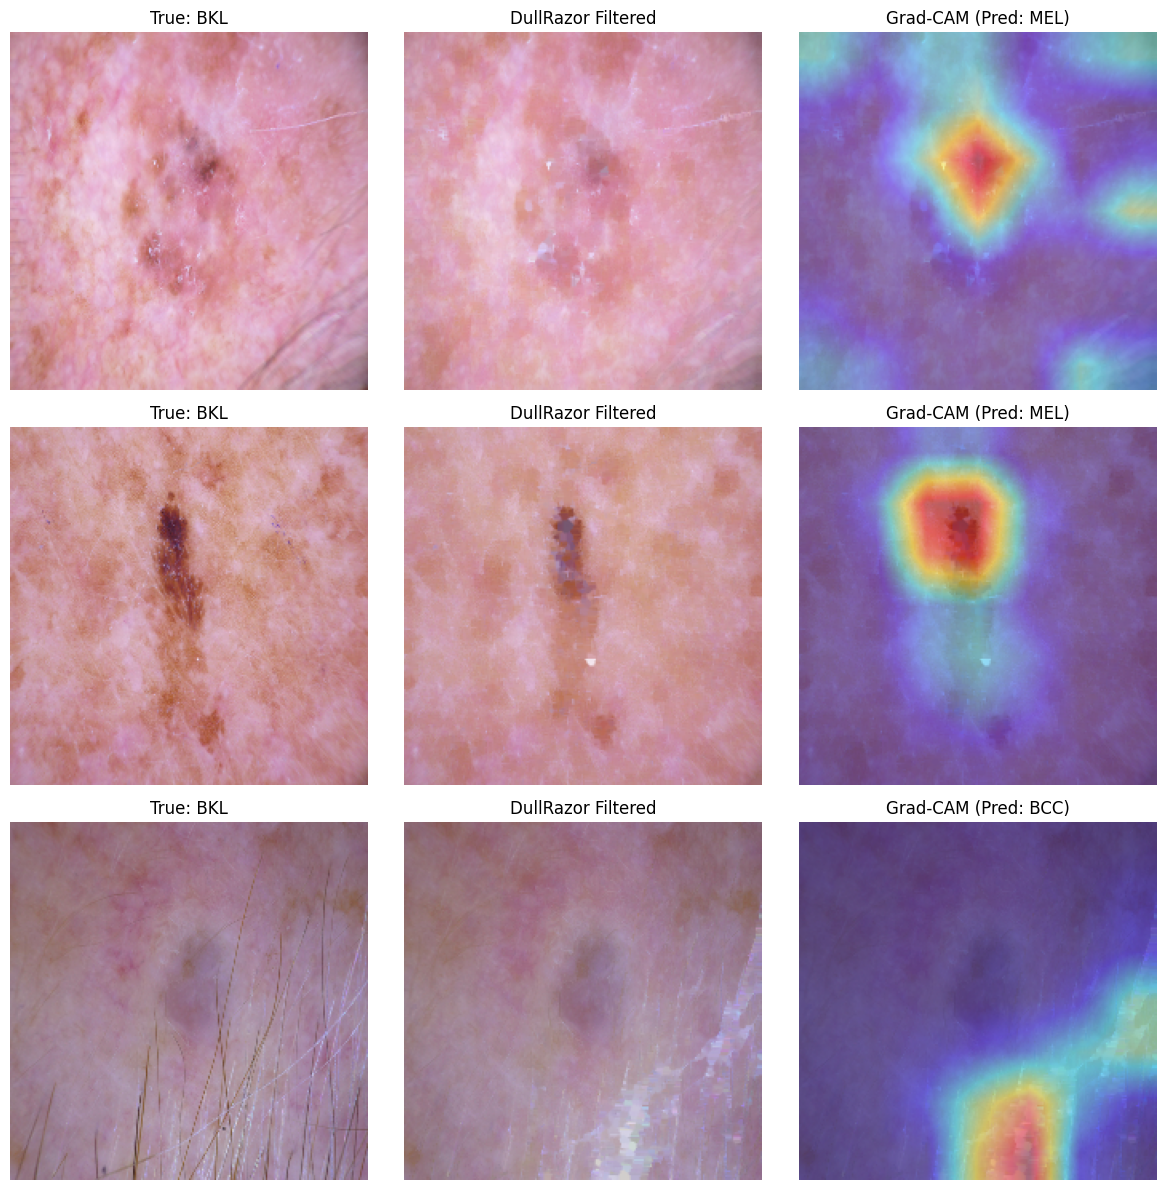

Genuine Grad-CAM Spatial Activation Heatmaps generated and saved.


In [56]:
def make_gradcam_heatmap(img_tensor, meta_tensor, model, backbone_layer):
    """
    Textbook Selvaraju et al. Gradient-Weighted Class Activation Mapping (Grad-CAM).
    L_Grad-CAM = ReLU( sum_k alpha_k * A^k )
    where alpha_k = (1/Z) * sum_i sum_j (d y_c / d A_ij^k)
    """
    img_tf = tf.convert_to_tensor(img_tensor, dtype=tf.float32)
    meta_tf = tf.convert_to_tensor(meta_tensor, dtype=tf.float32)

    conv_layer = backbone_layer.get_layer("top_conv")
    conv_extractor = keras.Model(inputs=backbone_layer.inputs, outputs=conv_layer.output)

    with tf.GradientTape() as tape:
        conv_features = conv_extractor(img_tf, training=False)
        tape.watch(conv_features)

        # Pass through M4 downstream classification head
        pool = model.get_layer("img_global_pool_g")(conv_features)
        d_i = model.get_layer("img_dense_embed_g")(pool)
        bn_i = model.get_layer("img_bn_g")(d_i)
        dr_i = model.get_layer("img_dropout_g")(bn_i)

        d_m1 = model.get_layer("meta_dense_1_g")(meta_tf)
        bn_m = model.get_layer("meta_bn_g")(d_m1)
        dr_m = model.get_layer("meta_dropout_g")(bn_m)
        d_m2 = model.get_layer("meta_dense_embed_g")(dr_m)

        rc = model.get_layer("raw_concat_g")([dr_i, d_m2])
        gt = model.get_layer("multimodal_gate_g")(rc)
        gt_act = model.get_layer("gated_interaction_g")([dr_i, gt])
        f_feat = model.get_layer("fused_features_g")([gt_act, d_m2])

        fd = model.get_layer("fusion_dense_g")(f_feat)
        f_dr = model.get_layer("fusion_dropout_g")(fd)
        preds = model.get_layer("classification_g")(f_dr)

        top_idx = int(tf.argmax(preds[0]))
        loss = preds[:, top_idx]

    # Gradients of winning class score w.r.t. convolutional feature maps
    grads = tape.gradient(loss, conv_features)
    # Global average pooling of gradients -> alpha_k channel importance weights
    alpha_weights = tf.reduce_mean(grads, axis=(1, 2))

    # Weighted linear combination: sum_k alpha_k * A^k
    cam = tf.reduce_sum(alpha_weights[:, tf.newaxis, tf.newaxis, :] * conv_features, axis=-1)
    cam = tf.maximum(cam[0], 0)  # Rectified Linear Unit (ReLU)
    cam = cam / (tf.reduce_max(cam) + 1e-7)

    heatmap = cv2.resize(cam.numpy(), (Config.IMAGE_WIDTH, Config.IMAGE_HEIGHT))
    return heatmap, top_idx

# Select diverse test samples for visualization
sample_indices = [0, 5, 12]
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))

for row_idx, idx in enumerate(sample_indices):
    sample_path = test_df.iloc[idx]["image_path"]
    sample_true_label = test_df.iloc[idx][Config.TARGET_COLUMN]
    sample_meta = np.expand_dims(x_test_metadata_processed[idx], axis=0)
    
    # Raw Image
    raw_img = cv2.imread(sample_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img = cv2.resize(raw_img, (Config.IMAGE_WIDTH, Config.IMAGE_HEIGHT))
    
    # DullRazor Cleaned
    cleaned_img = apply_dull_razor_np(open(sample_path, "rb").read())
    cleaned_tensor = np.expand_dims(cleaned_img, axis=0)
    
    # Genuine Grad-CAM Heatmap
    heatmap, pred_idx = make_gradcam_heatmap(cleaned_tensor, sample_meta, gated_fusion_model, gated_backbone)
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(cleaned_img.astype(np.uint8), 0.6, heatmap_color, 0.4, 0)
    
    pred_label = Config.CLASS_NAMES[pred_idx]
    
    axes[row_idx, 0].imshow(raw_img)
    axes[row_idx, 0].set_title(f"True: {sample_true_label.upper()}")
    axes[row_idx, 0].axis("off")
    
    axes[row_idx, 1].imshow(cleaned_img.astype(np.uint8))
    axes[row_idx, 1].set_title("DullRazor Filtered")
    axes[row_idx, 1].axis("off")
    
    axes[row_idx, 2].imshow(overlay)
    axes[row_idx, 2].set_title(f"Grad-CAM (Pred: {pred_label.upper()})")
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "gradcam_clinical_heatmaps.png"), dpi=300)
plt.show()
print("Genuine Grad-CAM Spatial Activation Heatmaps generated and saved.")

## 18. Demographic and Dataset Limitations Statement

### Scientific & Methodological Transparency:
1. **Demographic Label Availability:** The HAM10000 dataset contains patient metadata on age, sex, and anatomical lesion location collected from primary care clinics in Austria and Australia. However, **the dataset lacks explicit Fitzpatrick skin phototype annotations**. Consequently, skin-tone-stratified demographic fairness audits could not be directly quantified from ground truth.
2. **Clinical Scope:** This study presents an experimental research prototype evaluating multimodal feature fusion architectures and does not establish standalone clinical diagnostic validity. Clinical translation mandates multi-center prospective validation across diverse Fitzpatrick phototypes (IV–VI) and clinical camera dermatoscopy cohorts.